In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
BASE_DIR = r"E:\nidhi\simplilearn\capstone\project2\Part2_Tesla_Deaths_EDA"

DATA_PATH = os.path.join(BASE_DIR, "data", "Tesla - Deaths.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (307, 24)


In [4]:
df.head()

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,1,1,-,-,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns.tolist()

['Case #',
 'Year',
 'Date',
 ' Country ',
 ' State ',
 ' Description ',
 ' Deaths ',
 ' Tesla driver ',
 ' Tesla occupant ',
 ' Other vehicle ',
 ' Cyclists/ Peds ',
 ' TSLA+cycl / peds ',
 ' Model ',
 ' Autopilot claimed ',
 ' Verified Tesla Autopilot Deaths ',
 ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ',
 'Unnamed: 16',
 'Unnamed: 17',
 ' Source ',
 ' Note ',
 ' Deceased 1 ',
 ' Deceased 2 ',
 ' Deceased 3 ',
 ' Deceased 4 ']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 24 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                294 non-null    float64
 1   Year                                                                  294 non-null    float64
 2   Date                                                                  294 non-null    object 
 3    Country                                                              294 non-null    object 
 4    State                                                                294 non-null    object 
 5    Description                                                          295 non-null    object 
 6    Deaths                                                               299 non-null    float64
 7  

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

 Deceased 4                                                             307
 Deceased 3                                                             303
 Note                                                                   298
 Deceased 2                                                             290
 Deceased 1                                                             220
 Autopilot claimed                                                       26
Unnamed: 17                                                              18
 Tesla occupant                                                          17
Unnamed: 16                                                              15
Year                                                                     13
Case #                                                                   13
 Tesla driver                                                            13
 State                                                                   13
 Country    

In [8]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 4


In [9]:
df_clean = df.copy()

# Remove extra spaces from column names
df_clean.columns = df_clean.columns.str.strip()

df_clean.columns.tolist()

['Case #',
 'Year',
 'Date',
 'Country',
 'State',
 'Description',
 'Deaths',
 'Tesla driver',
 'Tesla occupant',
 'Other vehicle',
 'Cyclists/ Peds',
 'TSLA+cycl / peds',
 'Model',
 'Autopilot claimed',
 'Verified Tesla Autopilot Deaths',
 'Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO',
 'Unnamed: 16',
 'Unnamed: 17',
 'Source',
 'Note',
 'Deceased 1',
 'Deceased 2',
 'Deceased 3',
 'Deceased 4']

In [10]:
columns_to_drop = [
    "Unnamed: 16",
    "Unnamed: 17",
    "Source",
    "Note",
    "Deceased 1",
    "Deceased 2",
    "Deceased 3",
    "Deceased 4"
]

df_clean = df_clean.drop(columns=columns_to_drop, errors="ignore")

print("Shape after dropping unnecessary columns:", df_clean.shape)

Shape after dropping unnecessary columns: (307, 16)


In [11]:
# Remove rows where main identifying fields are missing
df_clean = df_clean.dropna(
    subset=["Case #", "Year", "Date", "Country", "Description"],
    how="all"
)

print("Shape after removing blank rows:", df_clean.shape)

Shape after removing blank rows: (295, 16)


In [12]:
print("Duplicate rows before:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("Duplicate rows after:", df_clean.duplicated().sum())
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows before: 0
Duplicate rows after: 0
Shape after removing duplicates: (295, 16)


In [13]:
numeric_columns = [
    "Case #",
    "Year",
    "Deaths",
    "Tesla driver",
    "Tesla occupant",
    "Other vehicle",
    "Cyclists/ Peds",
    "TSLA+cycl / peds",
    "Autopilot claimed",
    "Verified Tesla Autopilot Deaths",
    "Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO"
]

for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.strip()
            .replace({
                "-": "0",
                "": "0",
                "nan": "0",
                "NaN": "0"
            })
        )
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0)

print(df_clean[numeric_columns].dtypes)

Case #                                                                float64
Year                                                                  float64
Deaths                                                                float64
Tesla driver                                                            int64
Tesla occupant                                                          int64
Other vehicle                                                           int64
Cyclists/ Peds                                                          int64
TSLA+cycl / peds                                                        int64
Autopilot claimed                                                       int64
Verified Tesla Autopilot Deaths                                         int64
Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO      int64
dtype: object


In [16]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

print("Missing dates after conversion:", df_clean["Date"].isnull().sum())

df_clean[["Date", "Year"]].head()

Missing dates after conversion: 1


,Date,Year
0,2023-01-17,2022.0
1,2023-01-07,2022.0
2,2023-01-07,2022.0
3,2022-12-22,2022.0
4,2022-12-19,2022.0


In [18]:
df_clean["Year"] = df_clean["Year"].astype(int)

# If date is available, create clean year column from date
df_clean["Event_Year"] = df_clean["Date"].dt.year

# Use Event_Year where available, otherwise use Year
df_clean["Final_Year"] = df_clean["Event_Year"].fillna(df_clean["Year"]).astype(int)

df_clean[["Date", "Year", "Event_Year", "Final_Year"]].head()

,Date,Year,Event_Year,Final_Year
0,2023-01-17,2022,2023.0,2023
1,2023-01-07,2022,2023.0,2023
2,2023-01-07,2022,2023.0,2023
3,2022-12-22,2022,2022.0,2022
4,2022-12-19,2022,2022.0,2022


In [20]:
df_clean["Tesla_Driver_Died"] = df_clean["Tesla driver"] > 0
df_clean["Tesla_Occupant_Died"] = df_clean["Tesla occupant"] > 0
df_clean["Cyclist_or_Ped_Involved"] = df_clean["Cyclists/ Peds"] > 0
df_clean["Other_Vehicle_Involved"] = df_clean["Other vehicle"] > 0
df_clean["Autopilot_Claimed_Flag"] = df_clean["Autopilot claimed"] > 0
df_clean["Verified_Autopilot_Death_Flag"] = df_clean["Verified Tesla Autopilot Deaths"] > 0

df_clean.head()

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Event_Year,Final_Year,Tesla_Driver_Died,Tesla_Occupant_Died,Cyclist_or_Ped_Involved,Other_Vehicle_Involved,Autopilot_Claimed_Flag,Verified_Autopilot_Death_Flag
0,294.0,2022,2023-01-17,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0,0,2023.0,2023,True,False,False,False,False,False
1,293.0,2022,2023-01-07,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0,0,2023.0,2023,True,False,False,False,False,False
2,292.0,2022,2023-01-07,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0,0,2023.0,2023,False,True,False,False,False,False
3,291.0,2022,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,0,2022.0,2022,True,False,False,False,False,False
4,290.0,2022,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,0,2022.0,2022,False,False,True,False,False,False


In [21]:
df_clean.isnull().sum().sort_values(ascending=False)

Model                                                                 1
Date                                                                  1
Country                                                               1
State                                                                 1
Event_Year                                                            1
Verified Tesla Autopilot Deaths                                       0
Autopilot_Claimed_Flag                                                0
Other_Vehicle_Involved                                                0
Cyclist_or_Ped_Involved                                               0
Tesla_Occupant_Died                                                   0
Tesla_Driver_Died                                                     0
Final_Year                                                            0
Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO    0
Case #                                                          

In [22]:
cleaned_path = os.path.join(OUTPUT_DIR, "tesla_deaths_cleaned.csv")

df_clean.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved at:")
print(cleaned_path)

print("Final cleaned shape:", df_clean.shape)

Cleaned dataset saved at:
E:\nidhi\simplilearn\capstone\project2\Part2_Tesla_Deaths_EDA\outputs\tesla_deaths_cleaned.csv
Final cleaned shape: (295, 24)


In [24]:
print("Final cleaned shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nMissing values:")
print(df_clean.isnull().sum().sort_values(ascending=False))

df_clean.head()

Final cleaned shape: (295, 24)

Columns:
['Case #', 'Year', 'Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla driver', 'Tesla occupant', 'Other vehicle', 'Cyclists/ Peds', 'TSLA+cycl / peds', 'Model', 'Autopilot claimed', 'Verified Tesla Autopilot Deaths', 'Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO', 'Event_Year', 'Final_Year', 'Tesla_Driver_Died', 'Tesla_Occupant_Died', 'Cyclist_or_Ped_Involved', 'Other_Vehicle_Involved', 'Autopilot_Claimed_Flag', 'Verified_Autopilot_Death_Flag']

Missing values:
Model                                                                 1
Date                                                                  1
Country                                                               1
State                                                                 1
Event_Year                                                            1
Verified Tesla Autopilot Deaths                                       0
Autopilot_Claimed_Flag        

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Event_Year,Final_Year,Tesla_Driver_Died,Tesla_Occupant_Died,Cyclist_or_Ped_Involved,Other_Vehicle_Involved,Autopilot_Claimed_Flag,Verified_Autopilot_Death_Flag
0,294.0,2022,2023-01-17,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0,0,2023.0,2023,True,False,False,False,False,False
1,293.0,2022,2023-01-07,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0,0,2023.0,2023,True,False,False,False,False,False
2,292.0,2022,2023-01-07,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0,0,2023.0,2023,False,True,False,False,False,False
3,291.0,2022,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,0,2022.0,2022,True,False,False,False,False,False
4,290.0,2022,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,0,2022.0,2022,False,False,True,False,False,False


In [ ]:
#Total accidents and total deaths 
total_accidents = len(df_clean)
total_deaths = df_clean["Deaths"].sum()
avg_deaths_per_accident = df_clean["Deaths"].mean()

print("Total accident cases:", total_accidents)
print("Total deaths:", int(total_deaths))
print("Average deaths per accident:", round(avg_deaths_per_accident, 2))

Total accident cases: 295
Total deaths: 353
Average deaths per accident: 1.2


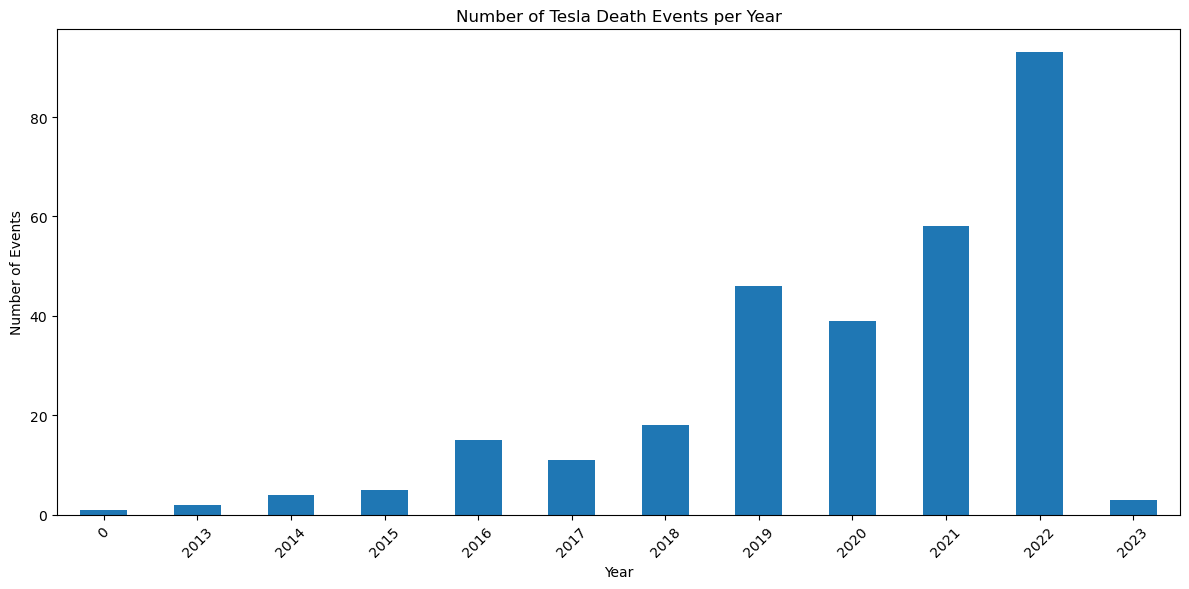

Final_Year
0        1
2013     2
2014     4
2015     5
2016    15
2017    11
2018    18
2019    46
2020    39
2021    58
2022    93
2023     3
dtype: int64

In [ ]:
#Accidents per year
accidents_per_year = df_clean.groupby("Final_Year").size()

plt.figure(figsize=(12, 6))
accidents_per_year.plot(kind="bar")
plt.title("Number of Tesla Death Events per Year")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "accidents_per_year.png"))
plt.show()

accidents_per_year

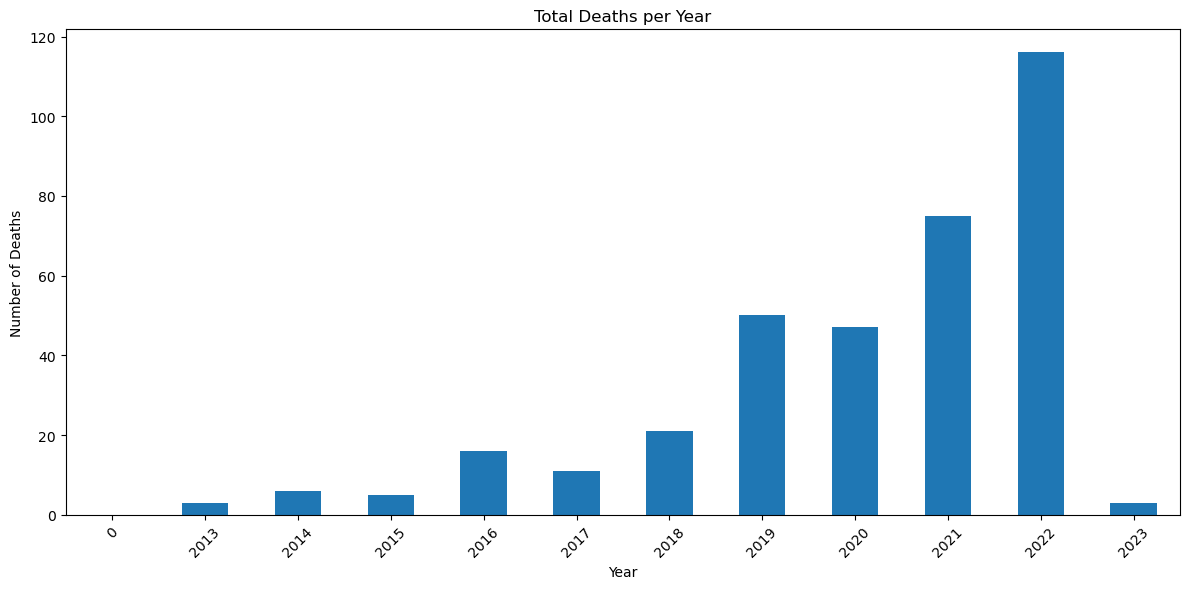

Final_Year
0         0.0
2013      3.0
2014      6.0
2015      5.0
2016     16.0
2017     11.0
2018     21.0
2019     50.0
2020     47.0
2021     75.0
2022    116.0
2023      3.0
Name: Deaths, dtype: float64

In [ ]:
#Deaths per year

deaths_per_year = df_clean.groupby("Final_Year")["Deaths"].sum()

plt.figure(figsize=(12, 6))
deaths_per_year.plot(kind="bar")
plt.title("Total Deaths per Year")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "deaths_per_year.png"))
plt.show()

deaths_per_year

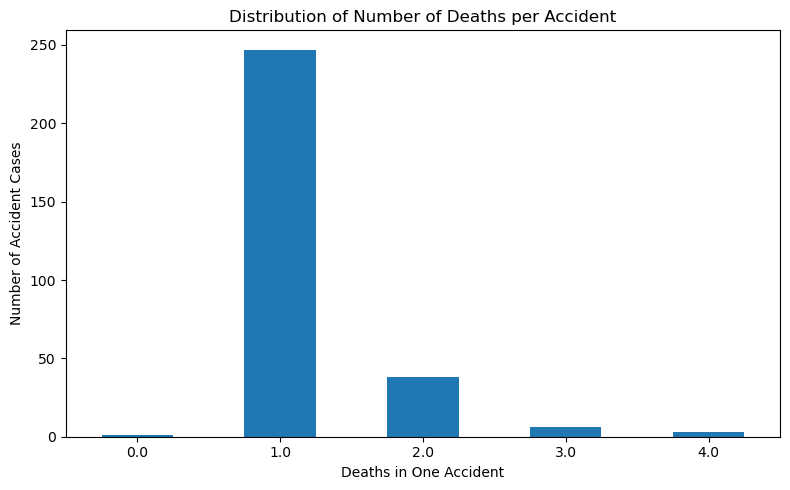

Deaths
0.0      1
1.0    247
2.0     38
3.0      6
4.0      3
Name: count, dtype: int64

In [28]:
#Number of victims in each accident

deaths_distribution = df_clean["Deaths"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
deaths_distribution.plot(kind="bar")
plt.title("Distribution of Number of Deaths per Accident")
plt.xlabel("Deaths in One Accident")
plt.ylabel("Number of Accident Cases")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "deaths_distribution.png"))
plt.show()

deaths_distribution

In [29]:
#Tesla driver deaths

tesla_driver_death_events = df_clean["Tesla_Driver_Died"].sum()
tesla_driver_deaths_total = df_clean["Tesla driver"].sum()

print("Accidents where Tesla driver died:", int(tesla_driver_death_events))
print("Total Tesla driver deaths:", int(tesla_driver_deaths_total))
print(
    "Percentage of accidents where Tesla driver died:",
    round((tesla_driver_death_events / len(df_clean)) * 100, 2),
    "%"
)

Accidents where Tesla driver died: 117
Total Tesla driver deaths: 117
Percentage of accidents where Tesla driver died: 39.66 %


In [30]:
#Tesla occupant deaths

tesla_occupant_death_events = df_clean["Tesla_Occupant_Died"].sum()
tesla_occupant_deaths_total = df_clean["Tesla occupant"].sum()

print("Accidents where one or more Tesla occupants died:", int(tesla_occupant_death_events))
print("Total Tesla occupant deaths:", int(tesla_occupant_deaths_total))
print(
    "Proportion of events with Tesla occupant death:",
    round((tesla_occupant_death_events / len(df_clean)) * 100, 2),
    "%"
)

Accidents where one or more Tesla occupants died: 43
Total Tesla occupant deaths: 48
Proportion of events with Tesla occupant death: 14.58 %


In [38]:
#Cyclist or pedestrian involvement

tesla_person_died = (df_clean["Tesla driver"] > 0) | (df_clean["Tesla occupant"] > 0)
cyclist_ped_died = df_clean["Cyclists/ Peds"] > 0

tesla_and_cyclist_ped_events = (tesla_person_died & cyclist_ped_died).sum()

tesla_and_cyclist_ped_deaths = df_clean.loc[
    tesla_person_died & cyclist_ped_died,
    ["Tesla driver", "Tesla occupant", "Cyclists/ Peds"]
].sum().sum()

print("Accidents involving Tesla driver/occupant death along with cyclist/pedestrian death:", int(tesla_and_cyclist_ped_events))
print("Total Tesla driver/occupant + cyclist/pedestrian deaths in those accidents:", int(tesla_and_cyclist_ped_deaths))

Accidents involving Tesla driver/occupant death along with cyclist/pedestrian death: 1
Total Tesla driver/occupant + cyclist/pedestrian deaths in those accidents: 2


In [32]:
#Tesla + cyclist/pedestrian combined deaths

tesla_cycl_ped_events = (df_clean["TSLA+cycl / peds"] > 0).sum()
tesla_cycl_ped_total = df_clean["TSLA+cycl / peds"].sum()

print("Events involving Tesla and cyclist/pedestrian deaths:", int(tesla_cycl_ped_events))
print("Total Tesla + cyclist/pedestrian combined deaths:", int(tesla_cycl_ped_total))

Events involving Tesla and cyclist/pedestrian deaths: 181
Total Tesla + cyclist/pedestrian combined deaths: 210


In [33]:
#Collision with other vehicles

other_vehicle_events = df_clean["Other_Vehicle_Involved"].sum()
other_vehicle_total = df_clean["Other vehicle"].sum()

print("Accidents involving other vehicles:", int(other_vehicle_events))
print("Total other vehicles involved:", int(other_vehicle_total))
print(
    "Percentage of accidents involving other vehicles:",
    round((other_vehicle_events / len(df_clean)) * 100, 2),
    "%"
)

Accidents involving other vehicles: 110
Total other vehicles involved: 130
Percentage of accidents involving other vehicles: 37.29 %


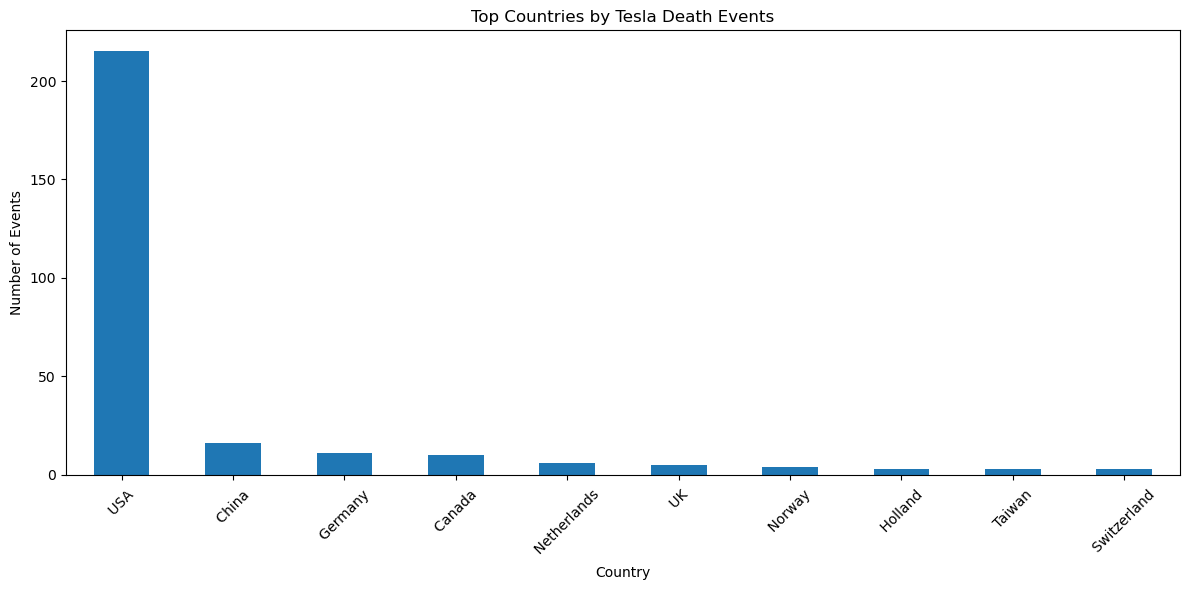

Country
USA             215
China            16
Germany          11
Canada           10
Netherlands       6
UK                5
Norway            4
Holland           3
Taiwan            3
Switzerland       3
Name: count, dtype: int64

In [34]:
#Country-wise accident distribution

country_distribution = df_clean["Country"].value_counts().head(10)

plt.figure(figsize=(12, 6))
country_distribution.plot(kind="bar")
plt.title("Top Countries by Tesla Death Events")
plt.xlabel("Country")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "country_distribution.png"))
plt.show()

country_distribution

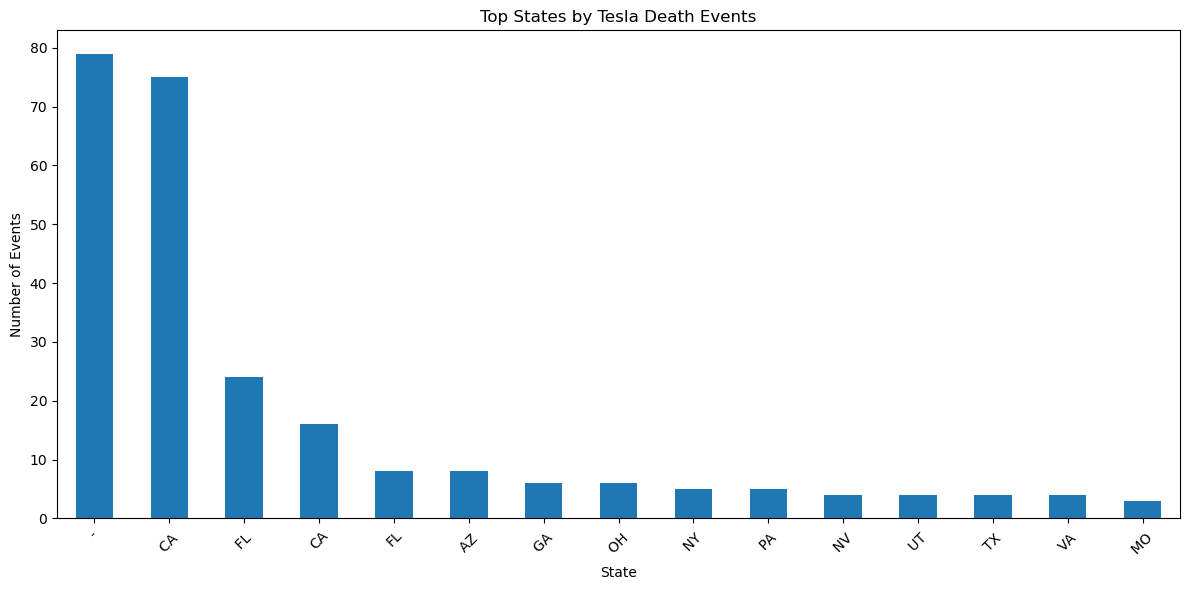

State
-       79
 CA     75
 FL     24
CA      16
FL       8
 AZ      8
 GA      6
 OH      6
 NY      5
 PA      5
 NV      4
 UT      4
 TX      4
 VA      4
 MO      3
Name: count, dtype: int64

In [35]:
#State-wise accident distribution
state_distribution = df_clean["State"].value_counts().head(15)

plt.figure(figsize=(12, 6))
state_distribution.plot(kind="bar")
plt.title("Top States by Tesla Death Events")
plt.xlabel("State")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "state_distribution.png"))
plt.show()

state_distribution

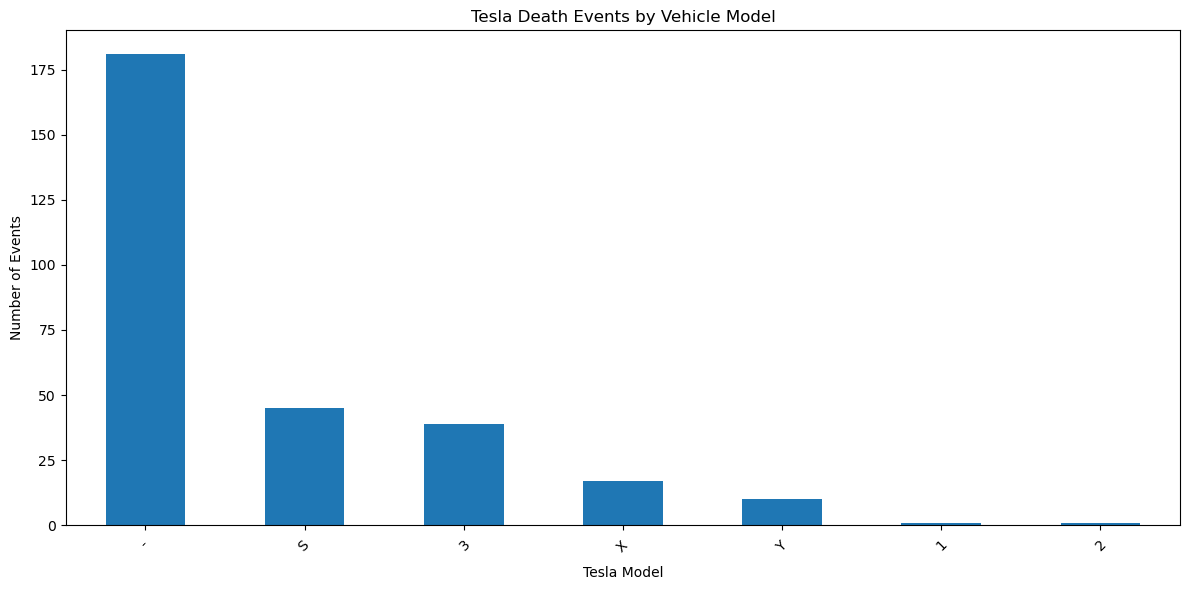

Model
-      181
S       45
 3      39
X       17
Y       10
 1       1
 2       1
Name: count, dtype: int64

In [39]:
#Event distribution across Tesla models
model_distribution = df_clean["Model"].value_counts()

plt.figure(figsize=(12, 6))
model_distribution.plot(kind="bar")
plt.title("Tesla Death Events by Vehicle Model")
plt.xlabel("Tesla Model")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "model_distribution.png"))
plt.show()

model_distribution

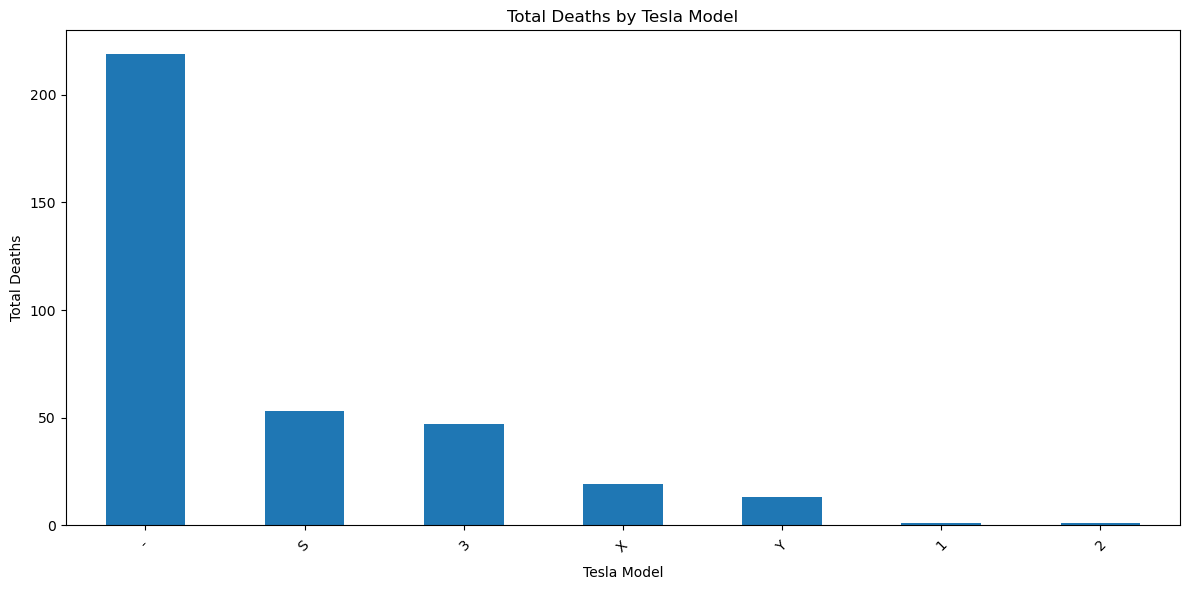

Model
-      219.0
S       53.0
 3      47.0
X       19.0
Y       13.0
 1       1.0
 2       1.0
Name: Deaths, dtype: float64

In [40]:
#Deaths by Tesla model

deaths_by_model = df_clean.groupby("Model")["Deaths"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
deaths_by_model.plot(kind="bar")
plt.title("Total Deaths by Tesla Model")
plt.xlabel("Tesla Model")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "deaths_by_model.png"))
plt.show()

deaths_by_model

In [41]:
#Autopilot claimed analysis
autopilot_claimed_events = df_clean["Autopilot_Claimed_Flag"].sum()
autopilot_claimed_deaths = df_clean.loc[
    df_clean["Autopilot_Claimed_Flag"],
    "Deaths"
].sum()

print("Accidents where Autopilot was claimed:", int(autopilot_claimed_events))
print("Deaths in Autopilot-claimed accidents:", int(autopilot_claimed_deaths))
print(
    "Percentage of accidents where Autopilot was claimed:",
    round((autopilot_claimed_events / len(df_clean)) * 100, 2),
    "%"
)

Accidents where Autopilot was claimed: 35
Deaths in Autopilot-claimed accidents: 43
Percentage of accidents where Autopilot was claimed: 11.86 %


In [44]:
#Verified Tesla Autopilot deaths
verified_autopilot_events = df_clean["Verified_Autopilot_Death_Flag"].sum()
verified_autopilot_deaths = df_clean["Verified Tesla Autopilot Deaths"].sum()

print("Events with verified Tesla Autopilot deaths:", int(verified_autopilot_events))
print("Total verified Tesla Autopilot deaths:", int(verified_autopilot_deaths))
print(
    "Percentage of events with verified Autopilot deaths:",
    round((verified_autopilot_events / len(df_clean)) * 100, 2),
    "%"
)

Events with verified Tesla Autopilot deaths: 16
Total verified Tesla Autopilot deaths: 19
Percentage of events with verified Autopilot deaths: 5.42 %


In [45]:
#Compare Autopilot claimed vs verified Autopilot deaths
autopilot_summary = pd.DataFrame({
    "Category": [
        "Autopilot Claimed",
        "Verified Autopilot Deaths"
    ],
    "Number of Events": [
        int(autopilot_claimed_events),
        int(verified_autopilot_events)
    ],
    "Total Deaths": [
        int(autopilot_claimed_deaths),
        int(verified_autopilot_deaths)
    ]
})

autopilot_summary

,Category,Number of Events,Total Deaths
0,Autopilot Claimed,35,43
1,Verified Autopilot Deaths,16,19


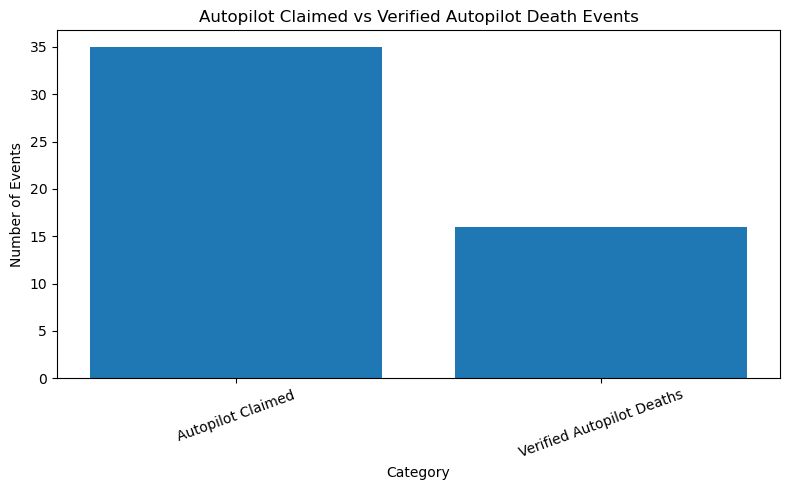

In [47]:
#Plot Autopilot comparison
plt.figure(figsize=(8, 5))
plt.bar(
    autopilot_summary["Category"],
    autopilot_summary["Number of Events"]
)
plt.title("Autopilot Claimed vs Verified Autopilot Death Events")
plt.xlabel("Category")
plt.ylabel("Number of Events")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "autopilot_claimed_vs_verified.png"))
plt.show()

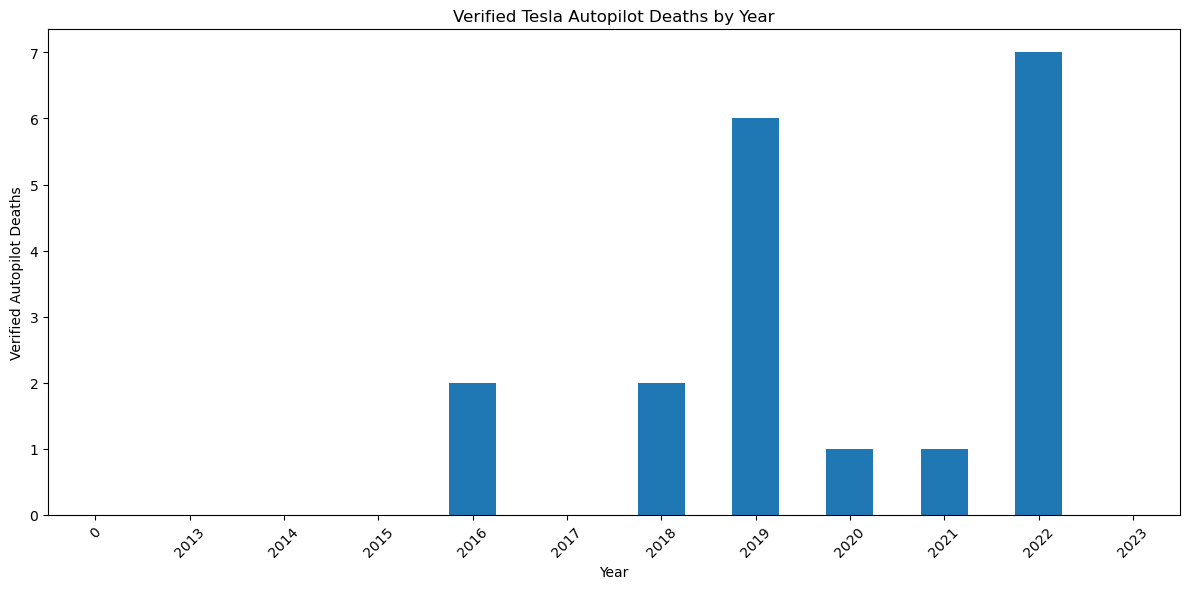

Final_Year
0       0
2013    0
2014    0
2015    0
2016    2
2017    0
2018    2
2019    6
2020    1
2021    1
2022    7
2023    0
Name: Verified Tesla Autopilot Deaths, dtype: int64

In [49]:
#Year-wise verified Autopilot deaths
verified_autopilot_by_year = df_clean.groupby("Final_Year")[
    "Verified Tesla Autopilot Deaths"
].sum()

plt.figure(figsize=(12, 6))
verified_autopilot_by_year.plot(kind="bar")
plt.title("Verified Tesla Autopilot Deaths by Year")
plt.xlabel("Year")
plt.ylabel("Verified Autopilot Deaths")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "verified_autopilot_deaths_by_year.png"))
plt.show()

verified_autopilot_by_year

In [50]:
#Save important summary metrics
summary_metrics = {
    "total_accident_cases": int(total_accidents),
    "total_deaths": int(total_deaths),
    "average_deaths_per_accident": round(float(avg_deaths_per_accident), 2),
    "tesla_driver_death_events": int(tesla_driver_death_events),
    "tesla_driver_deaths_total": int(tesla_driver_deaths_total),
    "tesla_occupant_death_events": int(tesla_occupant_death_events),
    "tesla_occupant_deaths_total": int(tesla_occupant_deaths_total),
    "cyclist_pedestrian_events": int(cyclist_ped_events),
    "cyclist_pedestrian_deaths_total": int(cyclist_ped_total),
    "other_vehicle_events": int(other_vehicle_events),
    "other_vehicle_total": int(other_vehicle_total),
    "autopilot_claimed_events": int(autopilot_claimed_events),
    "autopilot_claimed_deaths": int(autopilot_claimed_deaths),
    "verified_autopilot_events": int(verified_autopilot_events),
    "verified_autopilot_deaths": int(verified_autopilot_deaths)
}

summary_path = os.path.join(OUTPUT_DIR, "summary_metrics.csv")

pd.DataFrame([summary_metrics]).to_csv(summary_path, index=False)

print("Summary metrics saved at:")
print(summary_path)

pd.DataFrame([summary_metrics])

Summary metrics saved at:
E:\nidhi\simplilearn\capstone\project2\Part2_Tesla_Deaths_EDA\outputs\summary_metrics.csv


,total_accident_cases,total_deaths,average_deaths_per_accident,tesla_driver_death_events,tesla_driver_deaths_total,tesla_occupant_death_events,tesla_occupant_deaths_total,cyclist_pedestrian_events,cyclist_pedestrian_deaths_total,other_vehicle_events,other_vehicle_total,autopilot_claimed_events,autopilot_claimed_deaths,verified_autopilot_events,verified_autopilot_deaths
0,295,353,1.2,117,117,43,48,44,46,110,130,35,43,16,19


In [51]:
#Autopilot comparison table
autopilot_summary = pd.DataFrame({
    "Category": [
        "Autopilot Claimed",
        "Verified Autopilot Deaths"
    ],
    "Number of Events": [
        int(autopilot_claimed_events),
        int(verified_autopilot_events)
    ],
    "Total Deaths": [
        int(autopilot_claimed_deaths),
        int(verified_autopilot_deaths)
    ]
})

autopilot_summary

,Category,Number of Events,Total Deaths
0,Autopilot Claimed,35,43
1,Verified Autopilot Deaths,16,19


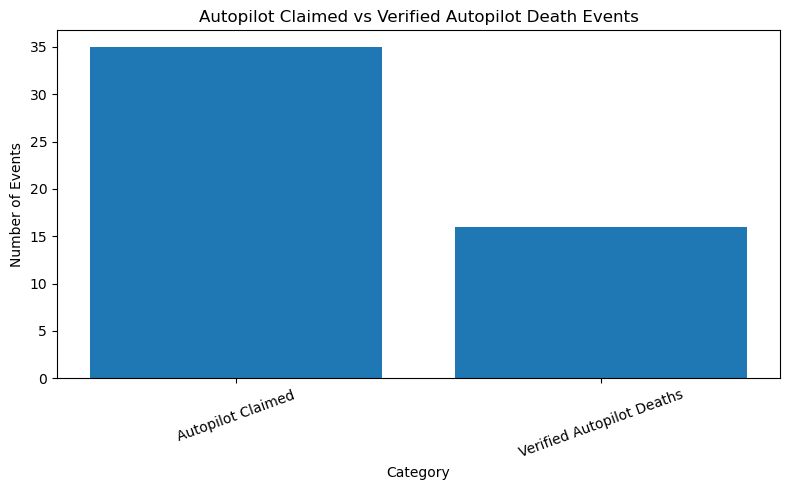

In [52]:
#Autopilot comparison chart
plt.figure(figsize=(8, 5))
plt.bar(
    autopilot_summary["Category"],
    autopilot_summary["Number of Events"]
)
plt.title("Autopilot Claimed vs Verified Autopilot Death Events")
plt.xlabel("Category")
plt.ylabel("Number of Events")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "autopilot_claimed_vs_verified.png"))
plt.show()

In [53]:
#Save final summary metrics
summary_metrics = {
    "total_accident_cases": int(total_accidents),
    "total_deaths": int(total_deaths),
    "average_deaths_per_accident": round(float(avg_deaths_per_accident), 2),

    "tesla_driver_death_events": int(tesla_driver_death_events),
    "tesla_driver_deaths_total": int(tesla_driver_deaths_total),

    "tesla_occupant_death_events": int(tesla_occupant_death_events),
    "tesla_occupant_deaths_total": int(tesla_occupant_deaths_total),

    "cyclist_pedestrian_events": int(cyclist_ped_events),
    "cyclist_pedestrian_deaths_total": int(cyclist_ped_total),

    "tesla_and_cyclist_pedestrian_events": int(tesla_and_cyclist_ped_events),
    "tesla_and_cyclist_pedestrian_deaths": int(tesla_and_cyclist_ped_deaths),

    "other_vehicle_events": int(other_vehicle_events),
    "other_vehicle_total": int(other_vehicle_total),

    "autopilot_claimed_events": int(autopilot_claimed_events),
    "autopilot_claimed_deaths": int(autopilot_claimed_deaths),

    "verified_autopilot_events": int(verified_autopilot_events),
    "verified_autopilot_deaths": int(verified_autopilot_deaths)
}

summary_path = os.path.join(OUTPUT_DIR, "summary_metrics.csv")

pd.DataFrame([summary_metrics]).to_csv(summary_path, index=False)

print("Summary metrics saved at:")
print(summary_path)

pd.DataFrame([summary_metrics])

Summary metrics saved at:
E:\nidhi\simplilearn\capstone\project2\Part2_Tesla_Deaths_EDA\outputs\summary_metrics.csv


,total_accident_cases,total_deaths,average_deaths_per_accident,tesla_driver_death_events,tesla_driver_deaths_total,tesla_occupant_death_events,tesla_occupant_deaths_total,cyclist_pedestrian_events,cyclist_pedestrian_deaths_total,tesla_and_cyclist_pedestrian_events,tesla_and_cyclist_pedestrian_deaths,other_vehicle_events,other_vehicle_total,autopilot_claimed_events,autopilot_claimed_deaths,verified_autopilot_events,verified_autopilot_deaths
0,295,353,1.2,117,117,43,48,44,46,1,2,110,130,35,43,16,19
